In [1]:
import os
import matplotlib.pyplot as plt

# Load standard libs
import sys
import pandas as pd

# Load custom code
from neuroencoders.utils.global_classes import Params, Project, save_project_to_pickle
from neuroencoders.utils.global_classes import DataHelper as DataHelperClass
from neuroencoders.importData import rawdata_parser
from neuroencoders.resultAnalysis import print_results
from neuroencoders.transformData.linearizer import UMazeLinearizer
from neuroencoders.utils import management, MOBS_Functions
from neuroencoders.fullEncoder import an_network as Training
from neuroencoders.importData.juliaData.julia_data_parser import julia_spike_filter
from neuroencoders.openEphysExport.generate_json import generate_json
import numpy as np
from importlib import reload
from neuroencoders.importData import epochs_management as ep

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
nameExp = "STRIDE_4_consensus_v1_factor3_dim64_3Transformers_lr001_nHeads4_dropout015_cLambda07_Transformer"
nameExp = "STRIDE_4_consensus_v7_factor3_dim64_3Transformers_lr001_nHeads4_dropout015_cLambda07_speed_75_50_Transformer"

In [4]:
jsonPath = None
windowSizeMS = [108]
mode = "ann"
target = "pos"
phase = "pre"
nEpochs = 200
mouse = "905"
manipe = "PAG"

In [5]:
from neuroencoders.utils.MOBS_Functions import path_for_experiments_df


Dir = path_for_experiments_df("Sub", nameExp)

## mobs_function

In [6]:
mice_nb = [
    "M1199_PAG",
    "M994_PAG",
    "M1182_PAG",
    "M1239_PAG",
    "M1162_PAG",
    "M905_PAG",
    "M1239_MFB",
    "M1162_MFB",
    "M1117_MFB",
    "M1168_MFB",
    "M1199_MFB1",
    "M1199_MFB2",
    "M1230_Known",
    "M1230_Novel",
    "M1199_reversal",
]
mice_names = [ m.split("_")[0].split("M")[1] for m in mice_nb ]
mice_manipes = [ m.split("_")[1] for m in mice_nb ]
# if mouse manipe is a string (eg mfb or pag) followed by a number, keep only the manipe name and add the number to exp_indices (else add 0 to exp_indices)
exp_indices = []
for m in mice_manipes:
    if m[-1].isdigit():
        exp_indices.append(int(m[-1]))
        mice_manipes[mice_manipes.index(m)] = m[:-1]
    else:
        exp_indices.append(0)

In [7]:
%matplotlib qt

In [8]:
from neuroencoders.utils.MOBS_Functions import Results_Loader, Mouse_Results
from pathlib import Path

In [9]:
try:
    loader = Results_Loader.from_pickle(path=os.path.join(Path.home(),"Documents","Theotime","DimaERCzz2","neuroencoders_1021","_work","consensus_noBayes.pickle")
)
except Exception as e:
    print(e)
    loader = Results_Loader(
        dir=Dir,
        mice_nb=mice_names,
        mice_manipes=mice_manipes,
        exp_indices = exp_indices,
        target="pos",
        timeWindows=windowSizeMS,
        phases=["pre", "cond", "post"],
        template="pre",
        verbose=False,
        which="ann",
        load_trainers_at_init = False,
        load_ann=False,
        load_bayes=False,
        load_bayesMatrices=False,
        load_pickle=False,
        deviceName="gpu",
        extract_spikes_count=False,
    )

[Errno 2] No such file or directory: '/home/mickey/Documents/Theotime/DimaERCzz2/neuroencoders_1021/_work/consensus_noBayes.pickle'
Path for 1199 found: /media/mickey/DataTheotime210/DimaERC2/neuroencoders_1021/_work/M1199_PAG
Windows found for 1199: ['108']
Loading DataHelper from /media/mickey/DataTheotime210/DimaERC2/neuroencoders_1021/_work/M1199_PAG/STRIDE_4_consensus_v7_factor3_dim64_3Transformers_lr001_nHeads4_dropout015_cLambda07_speed_75_50_Transformer/DataHelper_pre.pkl
found data_helper, using its custom lines
Linearization points have been created before


/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.10/site-packages/tables/attributeset.py:295: DataTypeWarning: Unsupported type for attribute 'MATLAB_fields' in node 'behavior'. Offending HDF5 class: 9
  value = self._g_getattr(self._v_node, name)
/home/mickey/Documents/Theotime/neuroEncoders/neuroencoders/utils/global_classes.py:564: UserWarning: old_positions already exist,meaning you already ran the true target ! beware.
  warn(
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.10/site-packages/shapely/measurement.py:81: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)


Loading saved params from /media/mickey/DataTheotime210/DimaERC2/neuroencoders_1021/_work/M1199_PAG/STRIDE_4_consensus_v7_factor3_dim64_3Transformers_lr001_nHeads4_dropout015_cLambda07_speed_75_50_Transformer/results/108/params.json
Looking for existing Params at: /media/mickey/DataTheotime210/DimaERC2/neuroencoders_1021/_work/M1199_PAG/STRIDE_4_consensus_v7_factor3_dim64_3Transformers_lr001_nHeads4_dropout015_cLambda07_speed_75_50_Transformer/results/108/Parameters.pkl
Loading existing Params from pickle file...
======================M1199=======================
Mouse_Results for 1199 (PAG)
Experiment: STRIDE_4_consensus_v7_factor3_dim64_3Transformers_lr001_nHeads4_dropout015_cLambda07_speed_75_50_Transformer
Target: PosAndHeadDirectionAndThigmo
Phase: pre
Path: /media/mickey/DataTheotime210/DimaERC2/neuroencoders_1021/_work/M1199_PAG
Windows: 108
======================M1199=======================
Mouse_Results for 1199 (PAG)
Experiment: STRIDE_4_consensus_v7_factor3_dim64_3Transforme

/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.10/site-packages/tables/attributeset.py:295: DataTypeWarning: Unsupported type for attribute 'MATLAB_fields' in node 'optional'. Offending HDF5 class: 9
  value = self._g_getattr(self._v_node, name)
/home/mickey/Documents/Theotime/neuroEncoders/.venv/lib/python3.10/site-packages/tables/attributeset.py:295: DataTypeWarning: Unsupported type for attribute 'MATLAB_fields' in node 'behavior'. Offending HDF5 class: 9
  value = self._g_getattr(self._v_node, name)


extending trainEpochs with lossPredSetEpochs as you're not using predLoss
found data_helper, using its custom lines
Linearization points have been created before
Loading saved params from /media/mickey/DataTheotime210/DimaERC2/neuroencoders_1021/_work/M1199_PAG/STRIDE_4_consensus_v7_factor3_dim64_3Transformers_lr001_nHeads4_dropout015_cLambda07_speed_75_50_Transformer/results/108/params.json
Looking for existing Params at: /media/mickey/DataTheotime210/DimaERC2/neuroencoders_1021/_work/M1199_PAG/STRIDE_4_consensus_v7_factor3_dim64_3Transformers_lr001_nHeads4_dropout015_cLambda07_speed_75_50_Transformer/results/108/Parameters.pkl
Loading existing Params from pickle file...
======================M1199=======================
Mouse_Results for 1199 (PAG)
Experiment: STRIDE_4_consensus_v7_factor3_dim64_3Transformers_lr001_nHeads4_dropout015_cLambda07_speed_75_50_Transformer
Target: pos
Phase: cond
Path: /media/mickey/DataTheotime210/DimaERC2/neuroencoders_1021/_work/M1199_PAG
Windows: 108
=

...

Converting 1230: 100%|██████████| 1/1 [00:00<00:00, 11305.40it/s]t]


Results for mouse 1230 and suffix '_cond' not found in resultsNN_phase. Skipping this suffix.


Converting 1230: 100%|██████████| 1/1 [00:00<00:00, 1201.46it/s]


Results for mouse 1230 and suffix '_post' not found in resultsNN_phase. Skipping this suffix.


Processing results: 100%|██████████| 45/45 [04:14<00:00,  5.65s/it]


In [10]:
loader.convert_to_df()

Results DataFrame for Results_Loader already exists. Use redo=True to recreate it.


,nameExp,mouse,manipe,phase,winMS,asymmetry_index,fullTruePos_fromBehavior,alignedTruePos_fromBehavior,fullTrueLinPos_from_behavior,alignedTrueLinPos_from_behavior,...,linPred,fullPred,truePos,linTruePos,predLoss,resultsNN,direction_fromBehavior,direction_fromNN,results,mouse_name
0,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1117,MFB,cond,108.0,2.063718,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5230964086687275, 0.9635114430407559], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5103733225940958, 0.5103733225940958, 0.510...",...,"[0.8944435, 0.4783476, 0.72312045, 0.49882552,...","[[0.9696053, 0.29654318, 1.84375, 0.046875], [...","[[0.5230964, 0.96351147, 2.5476277, 0.03648855...","[0.5103733, 0.5103733, 0.5103733, 0.5103733, 0...","[0.6777206, 0.5437002, 0.728269, 0.5795388, 0....","{'time': [[9302.15, 9302.193, 9302.24, 9302.28...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1117===================...,M1117MFB
1,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1117,MFB,post,108.0,5.729279,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5400851003553531, 0.9546482240980327], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5227936589315799, 0.5227936589315799, 0.522...",...,"[0.26868615, 0.36462894, 0.39340797, 0.432072,...","[[0.24952117, 0.78711647, 1.6328125, 0.1035156...","[[0.5400851, 0.9546482, -0.051067527, 0.045351...","[0.52279365, 0.52279365, 0.52279365, 0.5227936...","[0.59989613, 0.59250706, 0.6640104, 0.61912894...","{'time': [[16546.877, 16546.908, 16546.959, 16...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1117===================...,M1117MFB
2,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1117,MFB,pre,108.0,0.448039,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.08928227284151798, 0.031808919994720394, -...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.009595959792018636, 0.009595959792018636, 0...",...,"[0.038383838, 0.22070721, 0.23030324, 0.009595...","[[0.02849105, 0.10672046, 4.53125, 0.016967773...","[[0.089282274, 0.03180892, -0.70256966, 0.0318...","[0.009595959, 0.009595959, 0.009595959, 0.0095...","[0.59481096, 0.4639818, 0.40953428, 0.6248074,...","{'time': [[8803.42, 8803.446, 8803.491, 8803.5...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1117===================...,M1117MFB
3,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1117,MFB,training,108.0,0.448039,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.3965471685398473, 0.929816128045927, -2.62...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.4320720024770645, 0.4320720024770645, 0.432...",...,"[0.42240068, 0.41271076, 0.41271076, 0.4224006...","[[0.37916657, 0.946046, 3.453125, 0.08984375],...","[[0.39654717, 0.9298161, -2.6275218, 0.0701838...","[0.432072, 0.432072, 0.432072, 0.42240068, 0.4...","[0.5451472, 0.547827, 0.5587538, 0.61434007, 0...","{'time': [[8803.42, 8803.446, 8803.491, 8803.5...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1117===================...,M1117MFB
4,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1162,PAG,cond,108.0,0.131529,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.6930576412359497, 0.8983609533465587], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.6265038540776516, 0.6265038540776516, 0.626...",...,"[0.009595959, 0.2974744, 0.5103733, 0.3837951,...","[[0.087226704, 0.017624132, 4.0625, 0.06494140...","[[0.69305766, 0.89836097, 1.0794951, 0.1016390...","[0.6265038, 0.6265038, 0.6265038, 0.6265038, 0...","[0.60162365, 0.6562521, 0.74686784, 0.6934671,...","{'time': [[9075.195, 9075.227, 9075.292, 9075....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [38]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(data=loader.results_df.query("phase == 'cond'"), x="manipe", y="asymmetry_index", ax = ax)
ax.axhline(1, color='red', linestyle='--', label = "Symetric behaviour")
ax.legend()
fig.suptitle("Ratio of exploration between Shock and Safe arms during Conditioning Phase")


Text(0.5, 0.98, 'Ratio of exploration between Shock and Safe arms during Conditioning Phase')

In [39]:
# check if nameExp contains "LSTM" or "Transformer" to set the ann_mode row by row
loader.results_df["ann_mode"] = "Transformer"
loader.results_df.loc[
    loader.results_df["nameExp"].str.contains("LSTM"), "ann_mode"
] = "LSTM"

In [40]:
loader.results_df.columns

Index(['nameExp', 'mouse', 'manipe', 'phase', 'winMS', 'asymmetry_index',
       'fullTruePos_fromBehavior', 'alignedTruePos_fromBehavior',
       'fullTrueLinPos_from_behavior', 'alignedTrueLinPos_from_behavior',
       'fullTimeBehavior', 'alignedTimeBehavior', 'timeNN', 'fullSpeed',
       'alignedSpeed', 'posIndex_NN', 'speedMask', 'linPred', 'fullPred',
       'truePos', 'linTruePos', 'predLoss', 'resultsNN',
       'direction_fromBehavior', 'direction_fromNN', 'results', 'mouse_name',
       'ann_mode'],
      dtype='object')

In [41]:
loader.results_df.sort_values(by=["ann_mode", "mouse_name", "phase"], inplace=True)

In [42]:
loader.results_df

,nameExp,mouse,manipe,phase,winMS,asymmetry_index,fullTruePos_fromBehavior,alignedTruePos_fromBehavior,fullTrueLinPos_from_behavior,alignedTrueLinPos_from_behavior,...,fullPred,truePos,linTruePos,predLoss,resultsNN,direction_fromBehavior,direction_fromNN,results,mouse_name,ann_mode
0,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1117,MFB,cond,108.0,2.063718,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5230964086687275, 0.9635114430407559], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5103733225940958, 0.5103733225940958, 0.510...",...,"[[0.9696053, 0.29654318, 1.84375, 0.046875], [...","[[0.5230964, 0.96351147, 2.5476277, 0.03648855...","[0.5103733, 0.5103733, 0.5103733, 0.5103733, 0...","[0.6777206, 0.5437002, 0.728269, 0.5795388, 0....","{'time': [[9302.15, 9302.193, 9302.24, 9302.28...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1117===================...,M1117MFB,Transformer
1,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1117,MFB,post,108.0,5.729279,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5400851003553531, 0.9546482240980327], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5227936589315799, 0.5227936589315799, 0.522...",...,"[[0.24952117, 0.78711647, 1.6328125, 0.1035156...","[[0.5400851, 0.9546482, -0.051067527, 0.045351...","[0.52279365, 0.52279365, 0.52279365, 0.5227936...","[0.59989613, 0.59250706, 0.6640104, 0.61912894...","{'time': [[16546.877, 16546.908, 16546.959, 16...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1117===================...,M1117MFB,Transformer
2,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1117,MFB,pre,108.0,0.448039,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.08928227284151798, 0.031808919994720394, -...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.009595959792018636, 0.009595959792018636, 0...",...,"[[0.02849105, 0.10672046, 4.53125, 0.016967773...","[[0.089282274, 0.03180892, -0.70256966, 0.0318...","[0.009595959, 0.009595959, 0.009595959, 0.0095...","[0.59481096, 0.4639818, 0.40953428, 0.6248074,...","{'time': [[8803.42, 8803.446, 8803.491, 8803.5...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1117===================...,M1117MFB,Transformer
3,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1117,MFB,training,108.0,0.448039,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.3965471685398473, 0.929816128045927, -2.62...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.4320720024770645, 0.4320720024770645, 0.432...",...,"[[0.37916657, 0.946046, 3.453125, 0.08984375],...","[[0.39654717, 0.9298161, -2.6275218, 0.0701838...","[0.432072, 0.432072, 0.432072, 0.42240068, 0.4...","[0.5451472, 0.547827, 0.5587538, 0.61434007, 0...","{'time': [[8803.42, 8803.446, 8803.491, 8803.5...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1117===================...,M1117MFB,Transformer
5,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1162,MFB,cond,108.0,3.366857,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.26783386807114895, 0.8389348243362977], [0...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.3608926695896948, 0.3608926695896948, 0.360...",...,"[[0.017291665, 0.7420486, 0.8046875, 0.0066833...","[[0.26783386, 0.83893484, 0.62589234, 0.077003...","[0.36095777, 0.36095777, 0.36095777, 0.3609577...","[0.3733388, 0.37188387, 0.36853626, 0.3690905,...","{'time': [[10294.12, 10294.154, 10294.189, 102...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1162===================...,M1162MFB,Transformer
7,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1162,MFB,post,108.0,1.

In [23]:
loader.apply_analysis()

,nameExp,mouse,manipe,phase,winMS,asymmetry_index,fullTruePos_fromBehavior,alignedTruePos_fromBehavior,fullTrueLinPos_from_behavior,alignedTrueLinPos_from_behavior,...,mean_lin_error_selected,asymmetry_index_on_predicted,true_binary_direction,predicted_binary_direction,training_asymmetry_index,real_asymmetry_ratio,predicted_asymmetry_ratio,predicted_asymmetry_ratio_on_selected,predicted_asymmetry_ratio_normalized,selected_predicted_asymmetry_ratio_normalized
0,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1117,MFB,cond,36,1.990599,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5689448284491393, 0.9777851174419716], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5360426725910283, 0.5360426725910283, 0.536...",...,0.211989,0.500557,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, ...",0.465220,4.278834,1.075957,0.346535,0.116984,0.037677
1,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1117,MFB,cond,108,1.990599,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5689448284491393, 0.9777851174419716], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5360426725910283, 0.5360426725910283, 0.536...",...,0.246567,0.530190,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, ...",0.465220,4.278834,1.139655,1.995512,0.123910,0.216964
2,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1117,MFB,cond,252,1.990599,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5689448284491393, 0.9777851174419716], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5360426725910283, 0.5360426725910283, 0.536...",...,0.185803,0.493982,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ...",0.465220,4.278834,1.061824,3.633845,0.115448,0.395093
3,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1117,MFB,post,36,5.695101,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5440955082804306, 0.9519854501741697], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5227936589315799, 0.5227936589315799, 0.522...",...,0.532291,0.479915,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, ...","[0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, ...",0.465220,12.241738,1.031587,0.200018,0.039203,0.007601
4,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1117,MFB,post,108,5.695101,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5440955082804306, 0.9519854501741697], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5227936589315799, 0.5227936589315799, 0.522...",...,0.517412,0.639645,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, ...","[1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, ...",0.465220,12.241738,1.374931,1.084206,0.052251,0.041203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,994,PAG,pre,108,1.765149,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.1892896520246951, 0.10503854680125925, -2....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.040910172546584224, 0.040910172546584224, 0...",...,0.174791,3.759765,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, ...",1.765149,1.000000,2.129998,1.230930,3.759765,2.172775
176,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,994,PAG,pre,252,1.765149,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.1892896520246951, 0.10503854680125925, -2....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.040910172546584224, 0.040910172546584224, 0...",...,0.151653,3.111511,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, ...",1.765149,1.000000,1.762747,1.427303,3.111511,2.519403
177,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,994,PAG,training,36,1.765149,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.802539763175163, 0.04998183919827476, -2

In [43]:
loader.results_df.head()

,nameExp,mouse,manipe,phase,winMS,asymmetry_index,fullTruePos_fromBehavior,alignedTruePos_fromBehavior,fullTrueLinPos_from_behavior,alignedTrueLinPos_from_behavior,...,fullPred,truePos,linTruePos,predLoss,resultsNN,direction_fromBehavior,direction_fromNN,results,mouse_name,ann_mode
0,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1117,MFB,cond,108.0,2.063718,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5230964086687275, 0.9635114430407559], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5103733225940958, 0.5103733225940958, 0.510...",...,"[[0.9696053, 0.29654318, 1.84375, 0.046875], [...","[[0.5230964, 0.96351147, 2.5476277, 0.03648855...","[0.5103733, 0.5103733, 0.5103733, 0.5103733, 0...","[0.6777206, 0.5437002, 0.728269, 0.5795388, 0....","{'time': [[9302.15, 9302.193, 9302.24, 9302.28...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1117===================...,M1117MFB,Transformer
1,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1117,MFB,post,108.0,5.729279,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5400851003553531, 0.9546482240980327], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5227936589315799, 0.5227936589315799, 0.522...",...,"[[0.24952117, 0.78711647, 1.6328125, 0.1035156...","[[0.5400851, 0.9546482, -0.051067527, 0.045351...","[0.52279365, 0.52279365, 0.52279365, 0.5227936...","[0.59989613, 0.59250706, 0.6640104, 0.61912894...","{'time': [[16546.877, 16546.908, 16546.959, 16...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1117===================...,M1117MFB,Transformer
2,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1117,MFB,pre,108.0,0.448039,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.08928227284151798, 0.031808919994720394, -...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.009595959792018636, 0.009595959792018636, 0...",...,"[[0.02849105, 0.10672046, 4.53125, 0.016967773...","[[0.089282274, 0.03180892, -0.70256966, 0.0318...","[0.009595959, 0.009595959, 0.009595959, 0.0095...","[0.59481096, 0.4639818, 0.40953428, 0.6248074,...","{'time': [[8803.42, 8803.446, 8803.491, 8803.5...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1117===================...,M1117MFB,Transformer
3,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1117,MFB,training,108.0,0.448039,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.3965471685398473, 0.929816128045927, -2.62...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.4320720024770645, 0.4320720024770645, 0.432...",...,"[[0.37916657, 0.946046, 3.453125, 0.08984375],...","[[0.39654717, 0.9298161, -2.6275218, 0.0701838...","[0.432072, 0.432072, 0.432072, 0.42240068, 0.4...","[0.5451472, 0.547827, 0.5587538, 0.61434007, 0...","{'time': [[8803.42, 8803.446, 8803.491, 8803.5...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1117===================...,M1117MFB,Transformer
5,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1162,MFB,cond,108.0,3.366857,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.26783386807114895, 0.8389348243362977], [0...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.3608926695896948, 0.3608926695896948, 0.360...",...,"[[0.017291665, 0.7420486, 0.8046875, 0.0066833...","[[0.26783386, 0.83893484, 0.62589234, 0.077003...","[0.36095777, 0.36095777, 0.36095777, 0.3609577...","[0.3733388, 0.37188387, 0.36853626, 0.3690905,...","{'time': [[10294.12, 10294.154, 10294.189, 102...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1162===================...,M1162MFB,Transformer


In [44]:
main_dir = os.path.realpath(
    "/home/mickey/Dropbox/Mobs_member/Theotime_De_Charrin/Figures/"
)

/home/mickey/Documents/Theotime/neuroEncoders/neuroencoders/resultAnalysis/paper_figures.py:2751: RuntimeWarning: divide by zero encountered in divide
  H = H / H.max(axis=1)  # the max value of the histogram is 1
/home/mickey/Documents/Theotime/neuroEncoders/neuroencoders/resultAnalysis/paper_figures.py:2751: RuntimeWarning: invalid value encountered in divide
  H = H / H.max(axis=1)  # the max value of the histogram is 1


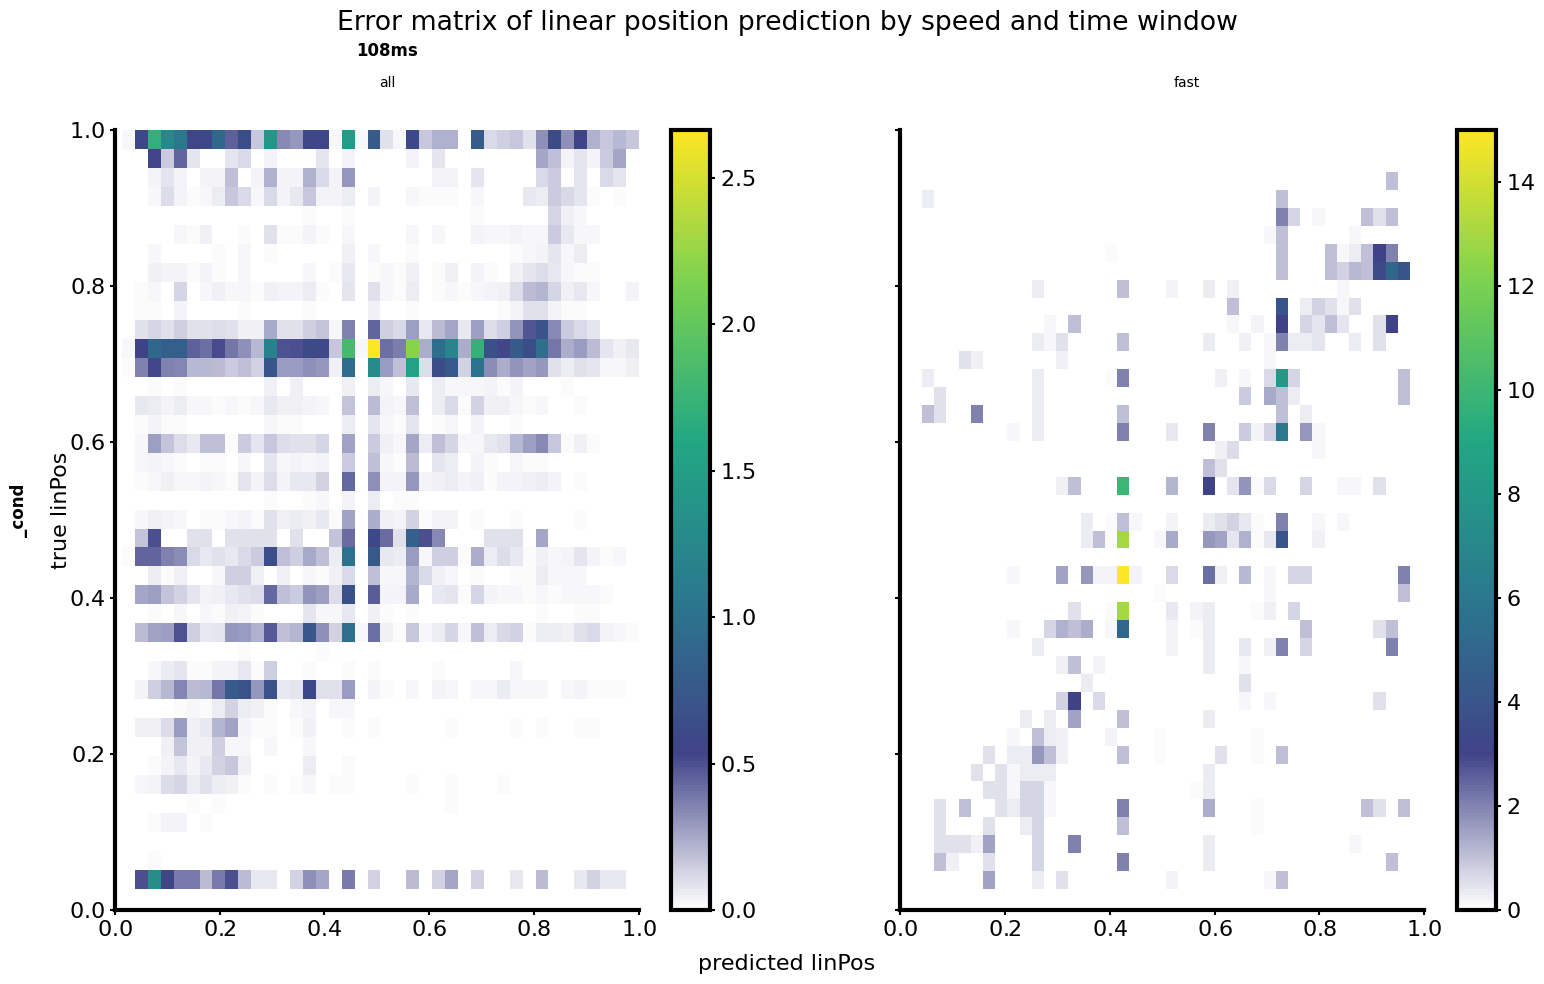

In [45]:
loader.results_dict[nameExp]["M994PAG"][
    "cond"
].error_matrix_linerrors_by_speed()

## save dataframe as mat struct

In [49]:
df

,nameExp,mouse,manipe,phase,winMS,asymmetry_index,fullTruePos_fromBehavior,alignedTruePos_fromBehavior,fullTrueLinPos_from_behavior,alignedTrueLinPos_from_behavior,...,fullPred,truePos,linTruePos,predLoss,resultsNN,direction_fromBehavior,direction_fromNN,results,mouse_name,ann_mode
0,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1117,MFB,cond,108.0,2.063718,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5230964086687275, 0.9635114430407559], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5103733225940958, 0.5103733225940958, 0.510...",...,"[[0.9696053, 0.29654318, 1.84375, 0.046875], [...","[[0.5230964, 0.96351147, 2.5476277, 0.03648855...","[0.5103733, 0.5103733, 0.5103733, 0.5103733, 0...","[0.6777206, 0.5437002, 0.728269, 0.5795388, 0....","{'time': [[9302.15, 9302.193, 9302.24, 9302.28...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1117===================...,M1117MFB,Transformer
1,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1117,MFB,post,108.0,5.729279,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5400851003553531, 0.9546482240980327], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5227936589315799, 0.5227936589315799, 0.522...",...,"[[0.24952117, 0.78711647, 1.6328125, 0.1035156...","[[0.5400851, 0.9546482, -0.051067527, 0.045351...","[0.52279365, 0.52279365, 0.52279365, 0.5227936...","[0.59989613, 0.59250706, 0.6640104, 0.61912894...","{'time': [[16546.877, 16546.908, 16546.959, 16...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1117===================...,M1117MFB,Transformer
2,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1117,MFB,pre,108.0,0.448039,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.08928227284151798, 0.031808919994720394, -...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.009595959792018636, 0.009595959792018636, 0...",...,"[[0.02849105, 0.10672046, 4.53125, 0.016967773...","[[0.089282274, 0.03180892, -0.70256966, 0.0318...","[0.009595959, 0.009595959, 0.009595959, 0.0095...","[0.59481096, 0.4639818, 0.40953428, 0.6248074,...","{'time': [[8803.42, 8803.446, 8803.491, 8803.5...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1117===================...,M1117MFB,Transformer
3,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1117,MFB,training,108.0,0.448039,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.3965471685398473, 0.929816128045927, -2.62...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.4320720024770645, 0.4320720024770645, 0.432...",...,"[[0.37916657, 0.946046, 3.453125, 0.08984375],...","[[0.39654717, 0.9298161, -2.6275218, 0.0701838...","[0.432072, 0.432072, 0.432072, 0.42240068, 0.4...","[0.5451472, 0.547827, 0.5587538, 0.61434007, 0...","{'time': [[8803.42, 8803.446, 8803.491, 8803.5...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1117===================...,M1117MFB,Transformer
5,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1162,MFB,cond,108.0,3.366857,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.26783386807114895, 0.8389348243362977], [0...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.3608926695896948, 0.3608926695896948, 0.360...",...,"[[0.017291665, 0.7420486, 0.8046875, 0.0066833...","[[0.26783386, 0.83893484, 0.62589234, 0.077003...","[0.36095777, 0.36095777, 0.36095777, 0.3609577...","[0.3733388, 0.37188387, 0.36853626, 0.3690905,...","{'time': [[10294.12, 10294.154, 10294.189, 102...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",======================M1162===================...,M1162MFB,Transformer
7,STRIDE_4_consensus_v7_factor3_dim64_3Transform...,1162,MFB,post,108.0,1.

In [50]:
from scipy.io import savemat

# Save the DataFrame as a .mat file

mdict = dict()
df = loader.results_df.copy()
for col in df.drop(columns=["results"]).columns:
    mdict[col] = df[col].to_numpy()

# Save the dictionary as a .mat file
savemat(os.path.join(main_dir, "..", "testdataKB_columns.mat"), mdict)

## save dataframe as csv file

In [48]:
loader.results_df.drop(columns=["results"]).to_csv(
    os.path.join(main_dir, "..", "dataKB.csv"), index=False
)

## analysis

In [27]:
import seaborn as sns

In [25]:
import plotly.express as px

px.scatter_matrix(
    loader.results_df[
        (loader.results_df.ann_mode == "Transformer")
        & (loader.results_df.phase == "pre")
        & (loader.results_df.winMS == 36)
    ],
    dimensions=[
        "training_asymmetry_index",
        "asymmetry_index_on_predicted",
        "mean_error",
        "predicted_asymmetry_ratio",
        "predicted_asymmetry_ratio_normalized",
    ],
    color="mouse",
    symbol="phase",
    title="Asymmetry Analysis for Transformer Model",
    width=1500,
    height=1500,
)

In [26]:
from matplotlib.colors import Normalize

corr = (
    loader.results_df.query("phase == 'pre'")
    .drop(columns="real_asymmetry_ratio")
    .corr(numeric_only=True)
)
sns.heatmap(
    corr,
    xticklabels=corr.columns.values,
    yticklabels=corr.columns.values,
    cmap="coolwarm",
    norm=Normalize(vmin=-1, vmax=1),
)

<Axes: >

In [27]:
import plotly.express as px

px.scatter_matrix(
    loader.results_df[
        (loader.results_df.ann_mode == "Transformer")
        & (loader.results_df.phase == "pre")
        & (loader.results_df.winMS == 252)
        & (loader.results_df.mouse != "M1230Known")
    ],
    dimensions=[
        "training_asymmetry_index",
        "asymmetry_index_on_predicted",
        "mean_error",
        "predicted_asymmetry_ratio",
        "predicted_asymmetry_ratio_normalized",
    ],
    color="mouse",
    symbol="phase",
    title="Asymmetry Analysis for Transformer Model",
    width=1500,
    height=1500,
)

In [29]:
loader.results_df.query("ann_mode == 'Transformer' & phase == 'pre' & winMS == 108")["mouse_name"].unique()

array(['M1117MFB', 'M1162MFB', 'M1162PAG', 'M1168MFB', 'M1182PAG',
       'M1199MFB_exp1', 'M1199MFB_exp2', 'M1199PAG', 'M1199reversal',
       'M1230Known', 'M1230Novel', 'M1239MFB', 'M1239PAG', 'M905PAG',
       'M994PAG'], dtype=object)

In [31]:
# plot a correlation plot between asymmetry_inded and mean_error, lin_error. hue by ann_mode and phase
sns.pairplot(
    loader.results_df.query("ann_mode == 'Transformer' & phase == 'pre'")[["mouse_name", "training_asymmetry_index", "asymmetry_index_on_predicted"]],
    x_vars=["training_asymmetry_index"],
    y_vars=["asymmetry_index_on_predicted"],
    hue="mouse_name",
    height=4.5,
    aspect=2,
)

In [33]:
loader.results_df.query("ann_mode == 'Transformer' & phase == 'pre'")[
    ["mouse", "winMS"]
].apply(tuple, axis=1)

6       (1117, 36)
7      (1117, 108)
8      (1117, 252)
24      (1162, 36)
25     (1162, 108)
26     (1162, 252)
27      (1162, 36)
28     (1162, 108)
29     (1162, 252)
42      (1168, 36)
43     (1168, 108)
44     (1168, 252)
54      (1182, 36)
55     (1182, 108)
56     (1182, 252)
90      (1199, 36)
91     (1199, 108)
92     (1199, 252)
93      (1199, 36)
94     (1199, 108)
95     (1199, 252)
84      (1199, 36)
85     (1199, 108)
86     (1199, 252)
87      (1199, 36)
88     (1199, 108)
89     (1199, 252)
123     (1230, 36)
124    (1230, 108)
125    (1230, 252)
120     (1230, 36)
121    (1230, 108)
122    (1230, 252)
144     (1239, 36)
145    (1239, 108)
146    (1239, 252)
147     (1239, 36)
148    (1239, 108)
149    (1239, 252)
162      (905, 36)
163     (905, 108)
164     (905, 252)
174      (994, 36)
175     (994, 108)
176     (994, 252)
dtype: object

In [34]:
loader.results_df.query("ann_mode == 'Transformer' & phase == 'pre' & winMS == 108")[
        [
            "real_asymmetry_ratio",
            "training_asymmetry_index",
            "predicted_asymmetry_ratio_normalized",
            "real_asymmetry_ratio",
            "predicted_asymmetry_ratio",
        ]
    ]

,real_asymmetry_ratio,training_asymmetry_index,predicted_asymmetry_ratio_normalized,real_asymmetry_ratio,predicted_asymmetry_ratio
7,1.0,0.465220,0.489632,1.0,1.052475
25,1.0,1.019774,0.903287,1.0,0.885772
28,1.0,1.297969,0.791776,1.0,0.610011
43,1.0,0.992274,1.460902,1.0,1.472277
55,1.0,1.053799,1.780262,1.0,1.689375
91,1.0,0.924860,2.073146,1.0,2.241578
94,1.0,0.906284,0.909682,1.0,1.003749
85,1.0,0.936069,0.994068,1.0,1.061960
88,1.0,1.171568,2.902376,1.0,2.477344
124,1.0,0.610147,0.425630,1.0,0.697586


In [35]:
sns.pairplot(
    loader.results_df.query("ann_mode == 'Transformer' & phase == 'pre' & winMS == 108")[
        [
            "mouse_name",
            "real_asymmetry_ratio",
            "training_asymmetry_index",
            "predicted_asymmetry_ratio_normalized",
            "predicted_asymmetry_ratio",
        ]
    ],
    x_vars="training_asymmetry_index",
    y_vars=        [
            "real_asymmetry_ratio",
            "predicted_asymmetry_ratio_normalized",
            "predicted_asymmetry_ratio",
        ],
    hue="mouse_name",
    height=4.5,
    aspect=1.5,
)

In [36]:
loader.results_df

,nameExp,mouse,manipe,phase,winMS,asymmetry_index,fullTruePos_fromBehavior,alignedTruePos_fromBehavior,fullTrueLinPos_from_behavior,alignedTrueLinPos_from_behavior,...,mean_lin_error_selected,asymmetry_index_on_predicted,true_binary_direction,predicted_binary_direction,training_asymmetry_index,real_asymmetry_ratio,predicted_asymmetry_ratio,predicted_asymmetry_ratio_on_selected,predicted_asymmetry_ratio_normalized,selected_predicted_asymmetry_ratio_normalized
0,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1117,MFB,cond,36,1.990599,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5689448284491393, 0.9777851174419716], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5360426725910283, 0.5360426725910283, 0.536...",...,0.211989,0.500557,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, ...",0.465220,4.278834,1.075957,0.346535,0.116984,0.037677
1,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1117,MFB,cond,108,1.990599,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5689448284491393, 0.9777851174419716], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5360426725910283, 0.5360426725910283, 0.536...",...,0.246567,0.530190,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, ...",0.465220,4.278834,1.139655,1.995512,0.123910,0.216964
2,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1117,MFB,cond,252,1.990599,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5689448284491393, 0.9777851174419716], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5360426725910283, 0.5360426725910283, 0.536...",...,0.185803,0.493982,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ...",0.465220,4.278834,1.061824,3.633845,0.115448,0.395093
3,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1117,MFB,post,36,5.695101,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5440955082804306, 0.9519854501741697], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5227936589315799, 0.5227936589315799, 0.522...",...,0.532291,0.479915,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, ...","[0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, ...",0.465220,12.241738,1.031587,0.200018,0.039203,0.007601
4,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1117,MFB,post,108,5.695101,"[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0.5440955082804306, 0.9519854501741697], [0....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.5227936589315799, 0.5227936589315799, 0.522...",...,0.517412,0.639645,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, ...","[1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, ...",0.465220,12.241738,1.374931,1.084206,0.052251,0.041203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,994,PAG,pre,108,1.765149,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.1892896520246951, 0.10503854680125925, -2....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.040910172546584224, 0.040910172546584224, 0...",...,0.174791,3.759765,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, ...",1.765149,1.000000,2.129998,1.230930,3.759765,2.172775
176,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,994,PAG,pre,252,1.765149,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.1892896520246951, 0.10503854680125925, -2....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.040910172546584224, 0.040910172546584224, 0...",...,0.151653,3.111511,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, ...",1.765149,1.000000,1.762747,1.427303,3.111511,2.519403
177,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,994,PAG,training,36,1.765149,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.802539763175163, 0.04998183919827476, -2

In [38]:
loader.results_df.columns[
            loader.results_df.columns.str.contains("asymmetry|error|mouse")
        ].drop("error")

Index(['mouse', 'asymmetry_index', 'mouse_name', 'mean_error', 'lin_error',
       'mean_lin_error', 'mean_error_selected',
       'asymmetry_index_on_selected_predicted', 'lin_error_selected',
       'mean_lin_error_selected', 'asymmetry_index_on_predicted',
       'training_asymmetry_index', 'real_asymmetry_ratio',
       'predicted_asymmetry_ratio', 'predicted_asymmetry_ratio_on_selected',
       'predicted_asymmetry_ratio_normalized',
       'selected_predicted_asymmetry_ratio_normalized'],
      dtype='object')

In [39]:
sns.pairplot(
    loader.results_df.query("ann_mode == 'Transformer' & phase == 'pre'")[
        loader.results_df.columns[
            loader.results_df.columns.str.contains("asymmetry|error|mouse")
        ].drop(["error", "lin_error", "lin_error_selected"])
    ],
    hue="mouse",
    height=4.5,
    aspect=1.5,
)

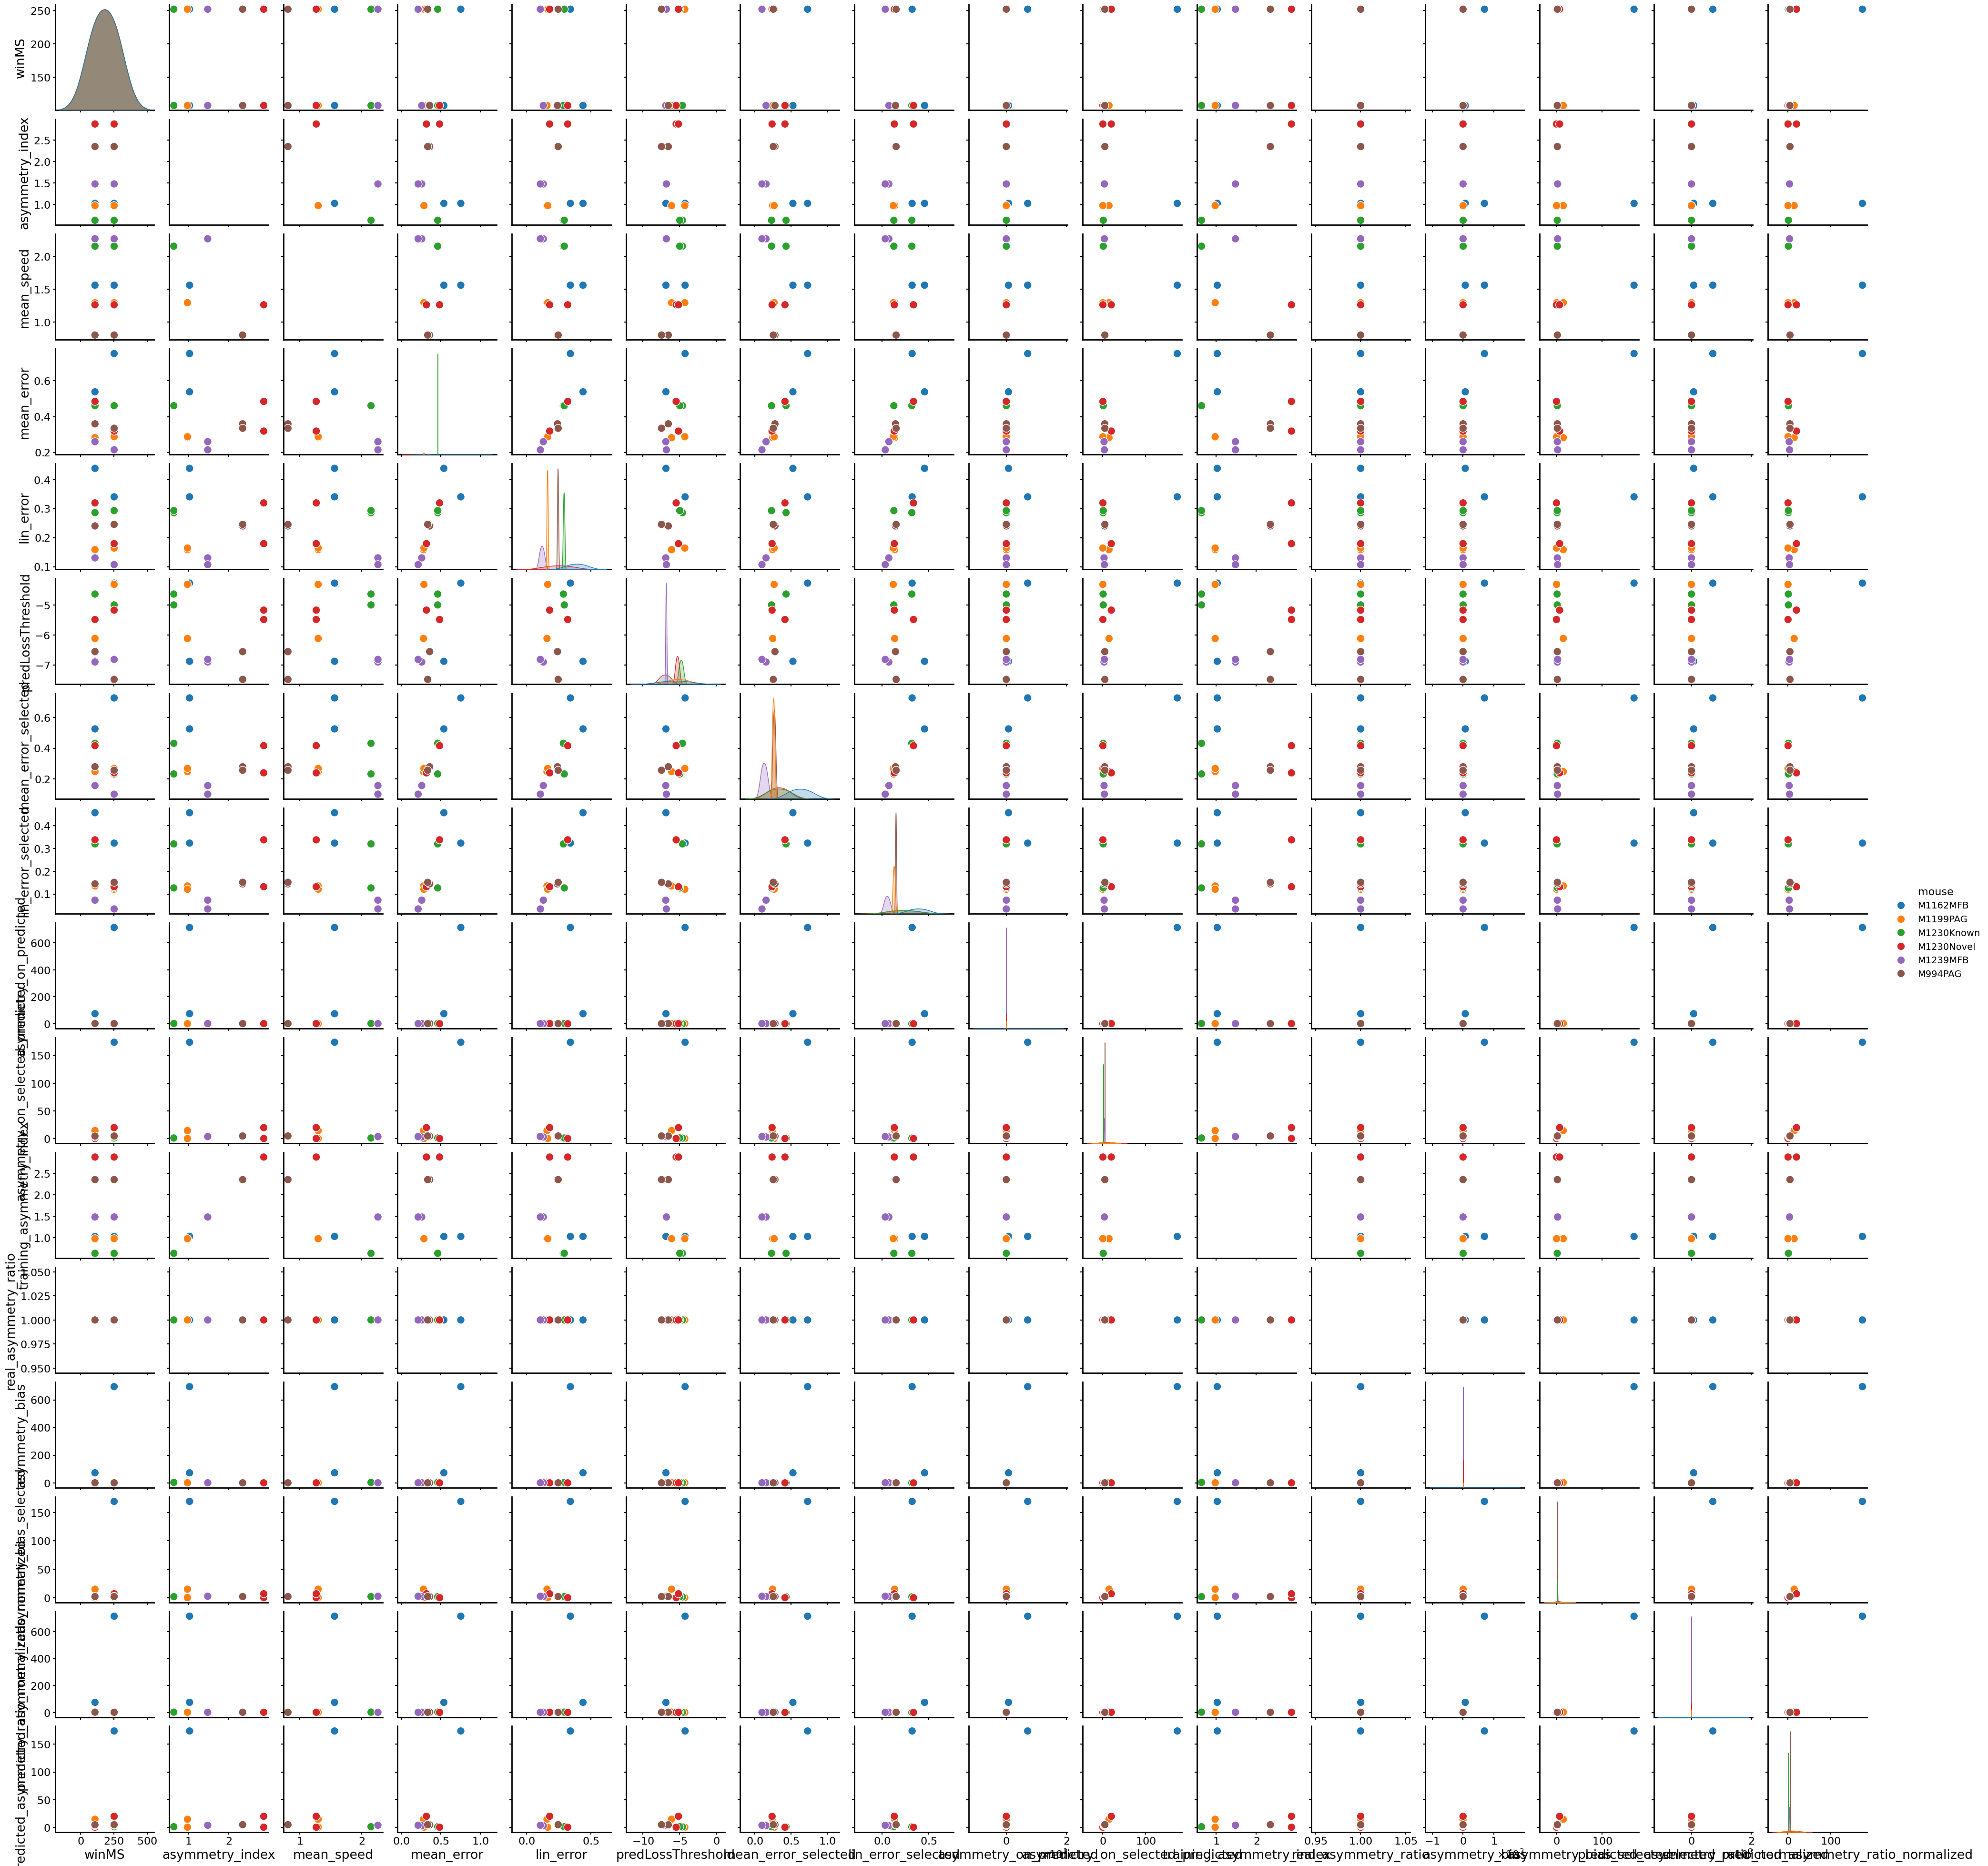

In [ ]:
sns.pairplot(
    loader.results_df.query("ann_mode == 'Transformer' & phase == 'pre'"),
    hue="mouse",
)

In [40]:
loader.results_df.query(
        "ann_mode == 'Transformer' & phase == 'pre' & winMS == 252"
    )

,nameExp,mouse,manipe,phase,winMS,asymmetry_index,fullTruePos_fromBehavior,alignedTruePos_fromBehavior,fullTrueLinPos_from_behavior,alignedTrueLinPos_from_behavior,...,mean_lin_error_selected,asymmetry_index_on_predicted,true_binary_direction,predicted_binary_direction,training_asymmetry_index,real_asymmetry_ratio,predicted_asymmetry_ratio,predicted_asymmetry_ratio_on_selected,predicted_asymmetry_ratio_normalized,selected_predicted_asymmetry_ratio_normalized
8,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1117,MFB,pre,252,0.465220,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.12698188576171826, 0.049127113157425184, -...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.019191919490909228, 0.019191919490909228, 0...",...,0.243980,0.286471,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, ...",0.465220,1.0,0.615775,0.538153,0.286471,0.250360
26,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1162,MFB,pre,252,1.019774,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.5910446342211169, 0.9323153964097181, 1.23...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.563980992786845, 0.563980992786845, 0.56398...",...,0.187458,0.811338,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, ...",1.019774,1.0,0.795606,0.787442,0.811338,0.803013
29,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1162,PAG,pre,252,1.297969,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.321405187296754, 0.08418638724341426, -1.1...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.028787879096671774, 0.028787879096671774, 0...",...,0.236272,0.788309,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, ...",1.297969,1.0,0.607340,0.773450,0.788309,1.003914
44,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1168,MFB,pre,252,0.992274,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.18194033645212648, 0.8787873251737971, 1.8...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.30707193867617566, 0.30707193867617566, 0.3...",...,0.124869,1.447332,"[0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, ...",0.992274,1.0,1.458602,0.853782,1.447332,0.847185
56,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1182,PAG,pre,252,1.053799,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.804620913589711, 0.9478656941043951, -0.76...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.6792254554212926, 0.6792254554212926, 0.691...",...,0.151354,2.635220,"[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, ...",1.053799,1.0,2.500685,3.039848,2.635220,3.203390
92,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1199,MFB,pre,252,0.924860,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.969617800900276, 0.8671510852992632, -2.20...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.7134555139999135, 0.7134555139999135, 0.713...",...,0.106737,2.129256,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, ...",0.924860,1.0,2.302246,2.898989,2.129256,2.681159
95,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1199,MFB,pre,252,0.906284,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.8849191924412795, 0.0568521875294781, 1.03...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.9808077357738425, 0.9808077357738425, 0.980...",...,0.150526,0.874583,"[0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, ...","[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.906284,1.0,0.965020,0.569284,0.874583,0.515933
86,STRIDE_4_consensus_v1_factor3_dim64_3Transform...,1199,PAG,pre,252,0.936069,"[[nan, nan, nan, inf], [nan, nan, nan, inf], [...","[[0.9411737852675914, 0.9316079340117376, -0.8...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.7029180408120441, 0.7029180408120441, 0.702...",...,0.121963,0.79

In [41]:
# plot a correlation plot between asymmetry_inded and mean_error, lin_error. hue by ann_mode and phase
sns.pairplot(
    loader.results_df.query(
        "ann_mode == 'Transformer' & phase == 'pre' & winMS == 252"
    ),
    x_vars=["training_asymmetry_index"],
    y_vars=["mean_error", "mean_lin_error"],
    hue="mouse_name",
    height=4.5,
    aspect=2,
)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [42]:
# plot a correlation plot between asymmetry_inded and mean_error, lin_error. hue by ann_mode and phase.
sns.pairplot(
    loader.results_df[
        (loader.results_df.ann_mode == "Transformer")
        & (loader.results_df.phase != "cond")
    ],
    x_vars=["training_asymmetry_index"],
    y_vars=["mean_error_selected", "lin_error_selected"],
    hue="winMS",
    height=4.5,
    aspect=1.5,
)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [103]:
import seaborn as sns

df = loader.results_df
# plot a correlation plot between asymmetry_inded and mean_error, lin_error. hue by ann_mode and phase.
sns.pairplot(
    df[(df.ann_mode == "Transformer") & (df.phase == "training")],
    x_vars=["asymmetry_index"],
    y_vars=["mean_error", "lin_error", "mean_error_selected", "lin_error_selected"],
    hue="winMS",
    kind="reg",
    diag_kind="kde",
)
sns.pairplot(
    df[(df.ann_mode == "Transformer")],
    x_vars=["asymmetry_index"],
    y_vars=["mean_error", "lin_error", "mean_error_selected", "lin_error_selected"],
    hue="phase",
    kind="reg",
    diag_kind="kde",
)
sns.pairplot(
    df[(df.ann_mode == "Transformer")],
    x_vars=["asymmetry_index"],
    y_vars=["predLossThreshold"],
    hue="phase",
    kind="reg",
    diag_kind="kde",
)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()